In [ ]:
!pip install scikit-optimize
!pip install --upgrade geopandas mapclassify folium
!pip install mapclassify==2.4.3
!pip install folium==0.12.1
!pip install geopandas==0.14.4
!pip install --upgrade folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: mapclassify
    Found existing installation: mapclassify 2.8.1
    Uninstalling mapclassify-2.8.1:
      Successfully uninstalled mapclassify-2.8.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: folium
    Found existing installation: folium 0.19.4
    Uninstalling folium-0.19.4:
      Successfully uninstalled folium-0.19.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
geemap 0.35.1 requires folium>=0.17.0, but you have folium 0.12.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import plotly.express as px
import mapclassify
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import KFold
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
from skopt import gp_minimize
from sklearn.metrics import make_scorer, median_absolute_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error, r2_score
import folium
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Read the smart location database dataset
smart_location_data = pd.read_csv("/content/sample_data/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv")
nj_counties = gpd.read_file("/content/sample_data/NJ_Counties_NGJIN_2021.geojson", driver = "GeoJSON")
nj_blockgroups_nhgis = gpd.read_file("/content/sample_data/nj_blockgroups_nhgis_webm.zip")
nj_blockgroups_nhgis.head()

#Set the display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#Explore the dataset
print(smart_location_data.head())
print(nj_blockgroups_nhgis.head())
#Get the unique values of the COUNTYFP 10 column for nj_blockgroups_nhgis

print(nj_blockgroups_nhgis.dtypes)
print(smart_location_data.info())
print(smart_location_data.dtypes)
print(smart_location_data.describe())
print(nj_counties.head())
print(nj_counties["FIPSCO"].unique())
print(nj_blockgroups_nhgis["COUNTYFP10"].unique())


   OBJECTID       GEOID10       GEOID20  STATEFP  COUNTYFP  TRACTCE  BLKGRPCE  \
0         1  4.811300e+11  4.811300e+11       48       113     7825         4   
1         2  4.811300e+11  4.811300e+11       48       113     7825         2   
2         3  4.811300e+11  4.811300e+11       48       113     7825         3   
3         4  4.811300e+11  4.811300e+11       48       113     7824         1   
4         5  4.811300e+11  4.811300e+11       48       113     7824         2   

     CSA                  CSA_Name     CBSA                        CBSA_Name  \
0  206.0  Dallas-Fort Worth, TX-OK  19100.0  Dallas-Fort Worth-Arlington, TX   
1  206.0  Dallas-Fort Worth, TX-OK  19100.0  Dallas-Fort Worth-Arlington, TX   
2  206.0  Dallas-Fort Worth, TX-OK  19100.0  Dallas-Fort Worth-Arlington, TX   
3  206.0  Dallas-Fort Worth, TX-OK  19100.0  Dallas-Fort Worth-Arlington, TX   
4  206.0  Dallas-Fort Worth, TX-OK  19100.0  Dallas-Fort Worth-Arlington, TX   

   CBSA_POP  CBSA_EMP  CBSA_WRK 

## Data Cleansing

In [ ]:
#Which columns has missing values and how many missing values are there?
columns_with_missing_values = smart_location_data.columns[smart_location_data.isnull().any()]
print(columns_with_missing_values)

Index(['GEOID10', 'CSA', 'CSA_Name', 'CBSA', 'CBSA_Name', 'CountHU', 'HH',
       'D1A', 'D1C8_OFF', 'D4D', 'D4E'],
      dtype='object')


In [ ]:
#Check for missing values in the dataset
print(smart_location_data.isnull().sum())

OBJECTID            0
GEOID10             1
GEOID20             0
STATEFP             0
COUNTYFP            0
TRACTCE             0
BLKGRPCE            0
CSA             53031
CSA_Name        53031
CBSA            17095
CBSA_Name       17095
CBSA_POP            0
CBSA_EMP            0
CBSA_WRK            0
Ac_Total            0
Ac_Water            0
Ac_Land             0
Ac_Unpr             0
TotPop              0
CountHU           275
HH                275
P_WrkAge            0
AutoOwn0            0
Pct_AO0             0
AutoOwn1            0
Pct_AO1             0
AutoOwn2p           0
Pct_AO2p            0
Workers             0
R_LowWageWk         0
R_MedWageWk         0
R_HiWageWk          0
R_PCTLOWWAGE        0
TotEmp              0
E5_Ret              0
E5_Off              0
E5_Ind              0
E5_Svc              0
E5_Ent              0
E8_Ret              0
E8_off              0
E8_Ind              0
E8_Svc              0
E8_Ent              0
E8_Ed               0
E8_Hlth   

In [ ]:
#Drop CSA, CSA_Name, CBSA, and CBSA_Name
smart_location_data.drop(["CSA", "CSA_Name", "CBSA", "CBSA_Name"], axis=1, inplace=True)

#Check for missing values
print(smart_location_data.isnull().sum())

OBJECTID          0
GEOID10           1
GEOID20           0
STATEFP           0
COUNTYFP          0
TRACTCE           0
BLKGRPCE          0
CBSA_POP          0
CBSA_EMP          0
CBSA_WRK          0
Ac_Total          0
Ac_Water          0
Ac_Land           0
Ac_Unpr           0
TotPop            0
CountHU         275
HH              275
P_WrkAge          0
AutoOwn0          0
Pct_AO0           0
AutoOwn1          0
Pct_AO1           0
AutoOwn2p         0
Pct_AO2p          0
Workers           0
R_LowWageWk       0
R_MedWageWk       0
R_HiWageWk        0
R_PCTLOWWAGE      0
TotEmp            0
E5_Ret            0
E5_Off            0
E5_Ind            0
E5_Svc            0
E5_Ent            0
E8_Ret            0
E8_off            0
E8_Ind            0
E8_Svc            0
E8_Ent            0
E8_Ed             0
E8_Hlth           0
E8_Pub            0
E_LowWageWk       0
E_MedWageWk       0
E_HiWageWk        0
E_PctLowWage      0
D1A             271
D1B               0
D1C               0


In [ ]:
#First do a correlation matrix on D1A column and
#the other columns to identify the strongest relationships.
correlation_matrix = smart_location_data.corr()
print(correlation_matrix["D1A"].sort_values(ascending=False))

D1A             1.000000
D1B             0.894412
D5BR            0.617105
D5BE            0.610632
AutoOwn0        0.544792
Pct_AO0         0.494454
D5AR            0.485268
D5AE            0.445192
D4B050          0.443651
D4B025          0.440683
D3AMM           0.427998
D1D             0.419703
CBSA_WRK        0.359771
CBSA_POP        0.358146
CBSA_EMP        0.357715
D3A             0.333680
D4A_Ranked      0.306149
D1C5_ENT        0.301394
D1C8_ENT        0.301394
D3BMM4          0.297254
D5DEI           0.266212
D5DRI           0.266211
D5DR            0.266211
D5DE            0.266211
D4A             0.265415
D4D             0.251427
NatWalkInd      0.248429
D1C5_RET        0.240323
D1C8_RET        0.240323
D4C             0.236314
D4E             0.236139
D3B             0.212393
D3BMM3          0.206075
D3B_Ranked      0.190920
D1C8_SVC        0.177816
D3APO           0.166819
D1C             0.157578
D5CRI           0.156958
D1C8_OFF        0.153542
P_WrkAge        0.138150


**Use Multivariate Imputation for D1A column**

In [ ]:
# Display missing values in the D1A column
print(f"Missing values in D1A before imputation: {smart_location_data['D1A'].isnull().sum()}")

# Select columns relevant for imputation (including D1A and related predictors)
columns_for_imputation = [
    'D1A',  # Target column for imputation
    'D1B',
    'D1C',
    'D5BR',
    'D5BE',
    'AutoOwn0',
    'D3B',
    'D1D',
    'D3A',
    'D4A'
]
# Ensure the selected columns exist in the dataset
data_imputation = smart_location_data[columns_for_imputation]

# Check for other missing values in the selected columns
print("Missing values in selected columns for imputation:")
print(data_imputation.isnull().sum())

# Initialize the IterativeImputer
imputer = IterativeImputer(random_state=0, max_iter=10)

# Apply imputation to the relevant columns
data_imputed = imputer.fit_transform(data_imputation)

# Convert the imputed array back to a DataFrame
data_imputed = pd.DataFrame(data_imputed, columns=columns_for_imputation)

# Replace the original D1A column with the imputed values
smart_location_data['D1A'] = data_imputed['D1A']

# Display the number of missing values after imputation
print(f"Missing values in D1A after imputation: {smart_location_data['D1A'].isnull().sum()}")
print(smart_location_data.head())

Missing values in D1A before imputation: 271
Missing values in selected columns for imputation:
D1A         271
D1B           0
D1C           0
D5BR          0
D5BE          0
AutoOwn0      0
D3B           0
D1D           0
D3A           0
D4A           0
dtype: int64
Missing values in D1A after imputation: 0
   OBJECTID       GEOID10       GEOID20  STATEFP  COUNTYFP  TRACTCE  BLKGRPCE  \
0         1  4.811300e+11  4.811300e+11       48       113     7825         4   
1         2  4.811300e+11  4.811300e+11       48       113     7825         2   
2         3  4.811300e+11  4.811300e+11       48       113     7825         3   
3         4  4.811300e+11  4.811300e+11       48       113     7824         1   
4         5  4.811300e+11  4.811300e+11       48       113     7824         2   

   CBSA_POP  CBSA_EMP  CBSA_WRK    Ac_Total  Ac_Water     Ac_Land     Ac_Unpr  \
0   7189384   3545715   3364458   73.595028       0.0   73.595028   73.595028   
1   7189384   3545715   3364458  119.829

**Use Multivariate Imputation for CountHU column**

In [ ]:
#First do a correlation matrix on CountHU column and
#the other columns to identify the strongest relationships.
correlation_matrix = smart_location_data.corr()
print(correlation_matrix["CountHU"].sort_values(ascending=False))

CountHU         1.000000
HH              0.941541
TotPop          0.827391
AutoOwn2p       0.771117
Workers         0.768175
R_LowWageWk     0.744979
AutoOwn1        0.743409
R_MedWageWk     0.700099
R_HiWageWk      0.685659
D2B_E8MIXA      0.237871
D2B_Ranked      0.237334
D2B_E5MIXA      0.225099
AutoOwn0        0.223258
E_LowWageWk     0.198896
E_MedWageWk     0.183254
E8_Ret          0.173189
E5_Ret          0.173189
E5_Ent          0.157953
E8_Ent          0.157953
TotEmp          0.157845
D2C_TRPMX2      0.137029
D2B_E5MIX       0.136475
D2B_E8MIX       0.129284
E8_Svc          0.129069
D2C_TRPMX1      0.126999
E_HiWageWk      0.115458
E5_Svc          0.111998
E8_off          0.099975
E5_Ind          0.084952
E8_Ind          0.084952
E5_Off          0.084054
E8_Hlth         0.061362
Pct_AO1         0.057466
D2R_WRKEMP      0.052196
Shape_Length    0.050385
D2C_TRIPEQ      0.048634
D1A             0.044439
Pct_AO2p        0.044385
P_WrkAge        0.040213
D2C_WREMLX      0.036927


In [ ]:
# Display missing values in the CountHU column
print(f"Missing values in CountHU before imputation: {smart_location_data['CountHU'].isnull().sum()}")

# Select columns relevant for imputation (including CountHU and related predictors)
columns_for_imputation = [
    'CountHU',  # Target column for imputation
    'HH',
    'TotPop',
    'AutoOwn2p',
    'Workers',
    'R_LowWageWk',
    'AutoOwn1',
    'R_MedWageWk',
    'R_HiWageWk',
    'D1A',
    'D1B',
    'D1C',
    'D3B'
]
# Ensure the selected columns exist in the dataset
data_imputation = smart_location_data[columns_for_imputation]

# Check for other missing values in the selected columns
print("Missing values in selected columns for imputation:")
print(data_imputation.isnull().sum())

# Initialize the IterativeImputer
imputer = IterativeImputer(random_state=0, max_iter=10)

# Apply imputation to the relevant columns
data_imputed = imputer.fit_transform(data_imputation)

# Convert the imputed array back to a DataFrame
data_imputed = pd.DataFrame(data_imputed, columns=columns_for_imputation)

# Replace the original CountHU column with the imputed values
smart_location_data['CountHU'] = data_imputed['CountHU']

# Display the number of missing values after imputation
print(f"Missing values in CountHU after imputation: {smart_location_data['CountHU'].isnull().sum()}")
print(smart_location_data.head())

Missing values in CountHU before imputation: 275
Missing values in selected columns for imputation:
CountHU        275
HH             275
TotPop           0
AutoOwn2p        0
Workers          0
R_LowWageWk      0
AutoOwn1         0
R_MedWageWk      0
R_HiWageWk       0
D1A              0
D1B              0
D1C              0
D3B              0
dtype: int64
Missing values in CountHU after imputation: 0
   OBJECTID       GEOID10       GEOID20  STATEFP  COUNTYFP  TRACTCE  BLKGRPCE  \
0         1  4.811300e+11  4.811300e+11       48       113     7825         4   
1         2  4.811300e+11  4.811300e+11       48       113     7825         2   
2         3  4.811300e+11  4.811300e+11       48       113     7825         3   
3         4  4.811300e+11  4.811300e+11       48       113     7824         1   
4         5  4.811300e+11  4.811300e+11       48       113     7824         2   

   CBSA_POP  CBSA_EMP  CBSA_WRK    Ac_Total  Ac_Water     Ac_Land     Ac_Unpr  \
0   7189384   3545715   33

**Use Multivariate Imputation for HH column**

In [ ]:
#First do a correlation matrix on HH column and
#the other columns to identify the strongest relationships.
correlation_matrix = smart_location_data.corr()
print(correlation_matrix["HH"].sort_values(ascending=False))

HH              1.000000
CountHU         0.941541
TotPop          0.900206
Workers         0.854328
AutoOwn2p       0.841318
R_LowWageWk     0.809727
R_HiWageWk      0.780923
R_MedWageWk     0.759167
AutoOwn1        0.757235
D2B_E8MIXA      0.253586
D2B_Ranked      0.251552
AutoOwn0        0.228070
D2B_E5MIXA      0.225138
E_LowWageWk     0.196314
E5_Ret          0.179129
E8_Ret          0.179129
E_MedWageWk     0.176255
TotEmp          0.155071
D2C_TRPMX2      0.144227
D2B_E8MIX       0.143150
D2B_E5MIX       0.137197
D2C_TRPMX1      0.133660
E8_Svc          0.129429
E5_Ent          0.119887
E8_Ent          0.119887
E5_Svc          0.116061
E_HiWageWk      0.114805
E8_off          0.097485
E8_Ind          0.093694
E5_Ind          0.093694
E5_Off          0.079767
Pct_AO2p        0.078725
P_WrkAge        0.073405
D2R_WRKEMP      0.070789
E8_Hlth         0.066588
D2C_TRIPEQ      0.051814
D3AAO           0.046161
D1A             0.044528
D2R_JOBPOP      0.036929
D3BAO           0.036270


In [ ]:
# Display missing values in the HH column
print(f"Missing values in HH before imputation: {smart_location_data['HH'].isnull().sum()}")

# Select columns relevant for imputation (including HH and related predictors)
columns_for_imputation = [
    'HH',  # Target column for imputation
    'CountHU',
    'TotPop',
    'AutoOwn2p',
    'Workers',
    'R_LowWageWk',
    'AutoOwn1',
    'R_MedWageWk',
    'R_HiWageWk',
    'D1A',
    'D1B',
    'D1C',
    'D3B'
]
# Ensure the selected columns exist in the dataset
data_imputation = smart_location_data[columns_for_imputation]

# Check for other missing values in the selected columns
print("Missing values in selected columns for imputation:")
print(data_imputation.isnull().sum())

# Initialize the IterativeImputer
imputer = IterativeImputer(random_state=0, max_iter=10)

# Apply imputation to the relevant columns
data_imputed = imputer.fit_transform(data_imputation)

# Convert the imputed array back to a DataFrame
data_imputed = pd.DataFrame(data_imputed, columns=columns_for_imputation)

# Replace the original HH column with the imputed values
smart_location_data['HH'] = data_imputed['HH']

# Display the number of missing values after imputation
print(f"Missing values in HH after imputation: {smart_location_data['HH'].isnull().sum()}")
print(smart_location_data.head())

Missing values in HH before imputation: 275
Missing values in selected columns for imputation:
HH             275
CountHU          0
TotPop           0
AutoOwn2p        0
Workers          0
R_LowWageWk      0
AutoOwn1         0
R_MedWageWk      0
R_HiWageWk       0
D1A              0
D1B              0
D1C              0
D3B              0
dtype: int64
Missing values in HH after imputation: 0
   OBJECTID       GEOID10       GEOID20  STATEFP  COUNTYFP  TRACTCE  BLKGRPCE  \
0         1  4.811300e+11  4.811300e+11       48       113     7825         4   
1         2  4.811300e+11  4.811300e+11       48       113     7825         2   
2         3  4.811300e+11  4.811300e+11       48       113     7825         3   
3         4  4.811300e+11  4.811300e+11       48       113     7824         1   
4         5  4.811300e+11  4.811300e+11       48       113     7824         2   

   CBSA_POP  CBSA_EMP  CBSA_WRK    Ac_Total  Ac_Water     Ac_Land     Ac_Unpr  \
0   7189384   3545715   3364458   73

In [ ]:
#Handle the rest of the missig values
print(smart_location_data.isnull().sum())

#Fill the rest of missing values with the mean for the numerical columns
smart_location_data.fillna(smart_location_data.mean(), inplace=True)

OBJECTID          0
GEOID10           1
GEOID20           0
STATEFP           0
COUNTYFP          0
TRACTCE           0
BLKGRPCE          0
CBSA_POP          0
CBSA_EMP          0
CBSA_WRK          0
Ac_Total          0
Ac_Water          0
Ac_Land           0
Ac_Unpr           0
TotPop            0
CountHU           0
HH                0
P_WrkAge          0
AutoOwn0          0
Pct_AO0           0
AutoOwn1          0
Pct_AO1           0
AutoOwn2p         0
Pct_AO2p          0
Workers           0
R_LowWageWk       0
R_MedWageWk       0
R_HiWageWk        0
R_PCTLOWWAGE      0
TotEmp            0
E5_Ret            0
E5_Off            0
E5_Ind            0
E5_Svc            0
E5_Ent            0
E8_Ret            0
E8_off            0
E8_Ind            0
E8_Svc            0
E8_Ent            0
E8_Ed             0
E8_Hlth           0
E8_Pub            0
E_LowWageWk       0
E_MedWageWk       0
E_HiWageWk        0
E_PctLowWage      0
D1A               0
D1B               0
D1C               0


Filter the dataset for New Jersey

In [ ]:
#Filter the dataset for New Jersey
smart_location_data = smart_location_data[smart_location_data["STATEFP"] == 34]
smart_location_data.head()
smart_location_data.shape

(6320, 113)

## Exploratory Data Analysis

In [ ]:
# Convert GEOID10 to string in both DataFrames
#smart_location_data['GEOID10'] = smart_location_data['GEOID10'].astype(str)
#nj_blockgroups_nhgis['GEOID10'] = nj_blockgroups_nhgis['GEOID10'].astype(str)

smart_location_data['COUNTYFP'] = smart_location_data['COUNTYFP'].astype(str).str.zfill(3)
smart_location_data['TRACTCE'] = smart_location_data['TRACTCE'].astype(str).str.zfill(6)
nj_counties['FIPSCO'] = nj_counties['FIPSCO'].astype(str).str.zfill(3)

smart_location_data["GEOID"] = smart_location_data["STATEFP"].astype(str) + smart_location_data["COUNTYFP"] + smart_location_data["TRACTCE"] + smart_location_data["BLKGRPCE"].astype(str)
smart_location_data.head()


# 1. Merge DataFrames (Assuming GEOID10 and GEOID are the common identifiers):
merged_data = pd.merge(smart_location_data, nj_blockgroups_nhgis, left_on='GEOID', right_on='GEOID10', how='inner')

print(merged_data["COUNTYFP10"].dtype)
print(nj_counties["FIPSCO"].dtype)

#Convert the FIPSCO column to int64
#nj_counties["FIPSCO"] = nj_counties["FIPSCO"].astype(int)

#Merge Dataframes merged_data with nj_counties
merged_data_counties = pd.merge(merged_data, nj_counties, left_on="COUNTYFP10", right_on="FIPSCO", how="inner")
merged_data_counties.head()

merged_data.head()

# 2. Create GeoDataFrame from merged data:
merged_gdf = gpd.GeoDataFrame(merged_data, geometry='geometry')
merged_gdf.head()

#merged_gdf.plot("NatWalkInd", cmap = 'viridis', legend = True, scheme='Quantiles')


object
object


,OBJECTID,GEOID10_x,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA_POP,CBSA_EMP,CBSA_WRK,Ac_Total,Ac_Water,Ac_Land,Ac_Unpr,TotPop,CountHU,HH,P_WrkAge,AutoOwn0,Pct_AO0,AutoOwn1,Pct_AO1,AutoOwn2p,Pct_AO2p,Workers,R_LowWageWk,R_MedWageWk,R_HiWageWk,R_PCTLOWWAGE,TotEmp,E5_Ret,E5_Off,E5_Ind,E5_Svc,E5_Ent,E8_Ret,E8_off,E8_Ind,E8_Svc,E8_Ent,E8_Ed,E8_Hlth,E8_Pub,E_LowWageWk,E_MedWageWk,E_HiWageWk,E_PctLowWage,D1A,D1B,D1C,D1C5_RET,D1C5_OFF,D1C5_IND,D1C5_SVC,D1C5_ENT,D1C8_RET,D1C8_OFF,D1C8_IND,D1C8_SVC,D1C8_ENT,D1C8_ED,D1C8_HLTH,D1C8_PUB,D1D,D1_FLAG,D2A_JPHH,D2B_E5MIX,D2B_E5MIXA,D2B_E8MIX,D2B_E8MIXA,D2A_EPHHM,D2C_TRPMX1,D2C_TRPMX2,D2C_TRIPEQ,D2R_JOBPOP,D2R_WRKEMP,D2A_WRKEMP,D2C_WREMLX,D3A,D3AAO,D3AMM,D3APO,D3B,D3BAO,D3BMM3,D3BMM4,D3BPO3,D3BPO4,D4A,D4B025,D4B050,D4C,D4D,D4E,D5AR,D5AE,D5BR,D5BE,D5CR,D5CRI,D5CE,D5CEI,D5DR,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area,GEOID,STATEFP10,COUNTYFP10,TRACTCE10,BLKGRPCE10,GEOID10_y,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,GISJOIN,Shape_area,Shape_len,geometry
0,141065,3.400300e+11,3.400300e+11,34,003,015200,5,19318471,9159786,8946175,51.444490,0.000000,51.444490,50.313740,1348,452.0,391.0,0.705,26,0.066496,94,0.240409,271,0.693095,385,84,120,181,0.218182,11,0,0,5,5,1,0,0,5,0,1,0,5,0,3,3,5,0.272727,8.983630,26.791886,0.218628,0.000000,0.000000,0.099376,0.099376,0.019875,0.000000,0.000000,0.099376,0.000000,0.019875,0.000000,0.099376,0.0,9.202258,0,0.028133,0.850864,0.580805,0.850864,0.449529,0.108946,0.122133,0.126451,2.844480e-09,0.016188,0.055556,35.000000,2.000000e-15,17.132550,0.000000,0.000000,17.132550,95.406913,0.000000,0.000000,0.000000,87.084156,37.321781,962.92,0.000000,0.000000,-99999.00,-99999.000000,-99999.000000,661739,595184,101107,158869,0.000098,0.542142,0.000100,0.617184,8.113230e-06,0.014519,2.473700e-05,0.058888,2,7,14,13,10.500000,1876.469931,2.081934e+05,340030152005,34,003,015200,5,340030152005,Block Group 5,G5030,S,208193,0,+40.9068551,-073.9772850,G34000300152005,2.081934e+05,1876.469960,"POLYGON ((-8234790.536 4998588.629, -8234822.0..."
1,141066,3.403510e+11,3.403510e+11,34,035,050902,1,19318471,9159786,8946175,1025.230008,3.882929,1021.347078,960.425575,1568,562.0,534.0,0.560,12,0.022472,120,0.224719,402,0.752809,932,151,128,653,0.162017,282,186,5,15,75,1,186,5,15,27,1,0,48,0,58,66,158,0.205674,0.585157,1.632610,0.293620,0.193664,0.005206,0.015618,0.078090,0.001041,0.193664,0.005206,0.015618,0.028113,0.001041,0.000000,0.049978,0.0,0.878777,0,0.528090,0.543226,0.543226,0.584939,0.504015,0.528428,0.600605,0.659669,9.075539e-01,0.304865,0.464580,3.304965,9.976234e-02,9.073748,1.034124,0.640540,7.399084,18.806849,5.012987,2.506494,0.000000,21.931820,2.506494,944.15,0.000000,0.000000,2.67,1.673085,0.001703,140212,128857,252,832,0.000021,0.114871,0.000022,0.133620,2.022150e-08,0.000036,1.295480e-07,0.000308,11,8,6,13,9.500000,11168.406450,4.149047e+06,340350509021,34,035,050902,1,340350509021,Block Group 1,G5030,S,4150399,21084,+40.5837777,-074.5303615,G34003500509021,4.171482e+06,11039.876871,"POLYGON ((-8295276.093 4951665.687, -8295060.8..."
2,141067,3.403510e+11,3.403510e+11,34,035,051000,2,19318471,9159786,8946175,1423.857411,119.495336,1304.362075,1252.374073,1859,544.0,544.0,0.557,13,0.023897,171,0.314338,360,0.661765,855,165,217,473,0.192982,4012,1011,73,1452,1130,346,1011,73,1452,1023,346,45,62,0,940,1117,1955,0.234297,0.434375,1.484381,3.203516,0.807267,0.058289,1.159398,0.902286,0.276275,0.807267,0.058289,1.159398,0.816849,0.276275,0.035932,0.049506,0.0,3.637891,0,7.375000,0.842710,0.842710,0.751662,0.703394,0.870696,0.756430,0.774000,3.983188e-01,0.633282,0.351346,0.213111,4.552588e-01,8.520130,1.210058,1.815309,5.494763,37.796131,1.962645,14.719839,1.962645,30.911662,5.397274,839.54,0.090208,0.288133,4.67,2.291388,0.002512,158876,139298,6592,8776,0.000024,0.130162,0.000023,0.144447,5.289680e-07,0.000947,1.366480e-06,0.003253,20,16,8,13,13.000000,10427.772280,5.762272e+06,340350510002,34,0

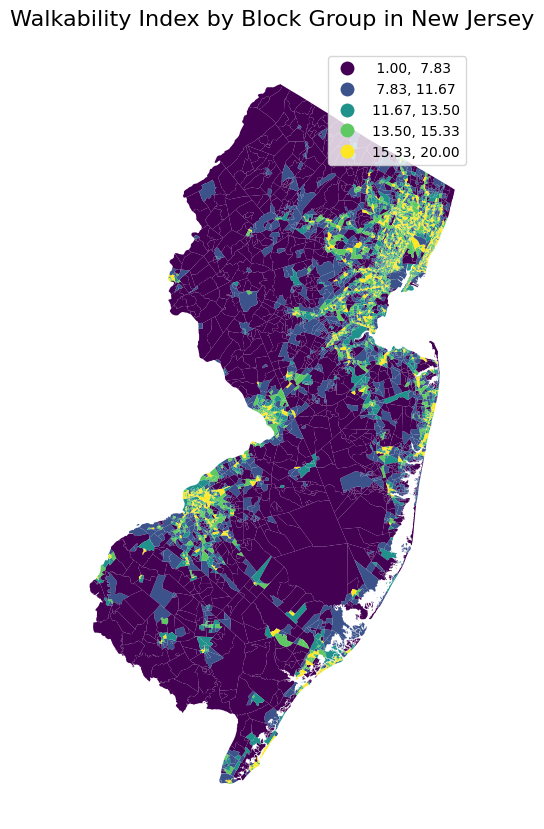

In [ ]:
# Create a map to show NJ Walkability
fig, ax = plt.subplots(1, 1, figsize=(12, 10))  # Adjust figsize as needed

# Plot the data
merged_gdf.plot(
    column="NatWalkInd",
    cmap="viridis",
    legend=True,
    scheme="Quantiles",
    ax=ax,  # Specify the axes to plot on
)

# Remove axes markings
ax.set_axis_off()

#Add a title
ax.set_title("Walkability Index by Block Group in New Jersey", fontsize=16, loc="center")



# Display the plot
plt.show()

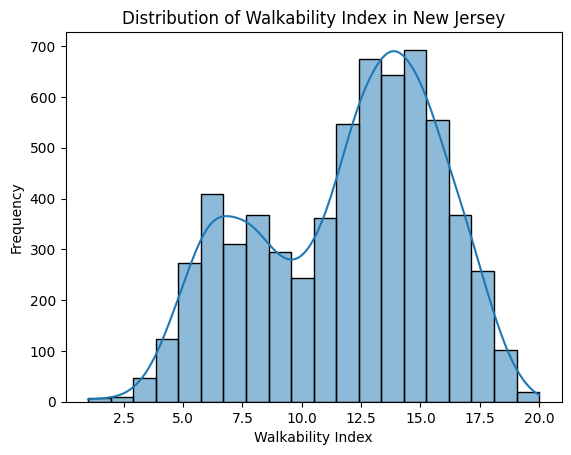

In [ ]:
#Histogram of Walkability Index
sns.histplot(merged_gdf["NatWalkInd"], bins=20, kde=True)  # kde=True for a smoothed curve
plt.xlabel("Walkability Index")
plt.ylabel("Frequency")
plt.title("Distribution of Walkability Index in New Jersey")
plt.show()

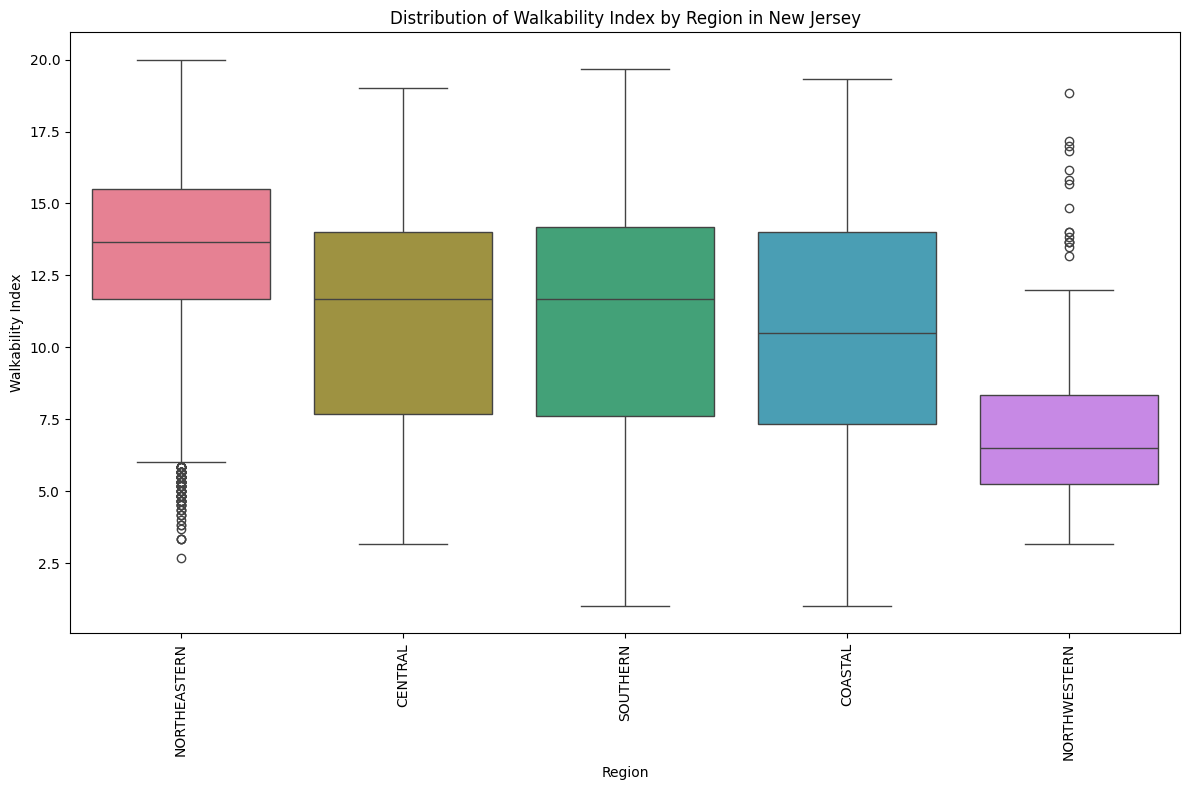

In [ ]:
#Sort regions by median Walkability Index
sorted_data = merged_data_counties.copy()
sorted_data['REGION'] = pd.Categorical(
    sorted_data['REGION'],
    categories=sorted_data.groupby('REGION')['NatWalkInd'].median().sort_values(ascending=False).index,
    ordered=True
)

#Set a color palette with unique colors for each box
palette = sns.color_palette("husl", n_colors=sorted_data['REGION'].nunique())

#Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(
    x="REGION",
    y="NatWalkInd",
    data=sorted_data,
    palette=palette
)
plt.xlabel("Region")
plt.ylabel("Walkability Index")
plt.title("Distribution of Walkability Index by Region in New Jersey")
plt.xticks(rotation=90)
plt.tight_layout()  # Adjust layout for better visibility
plt.show()

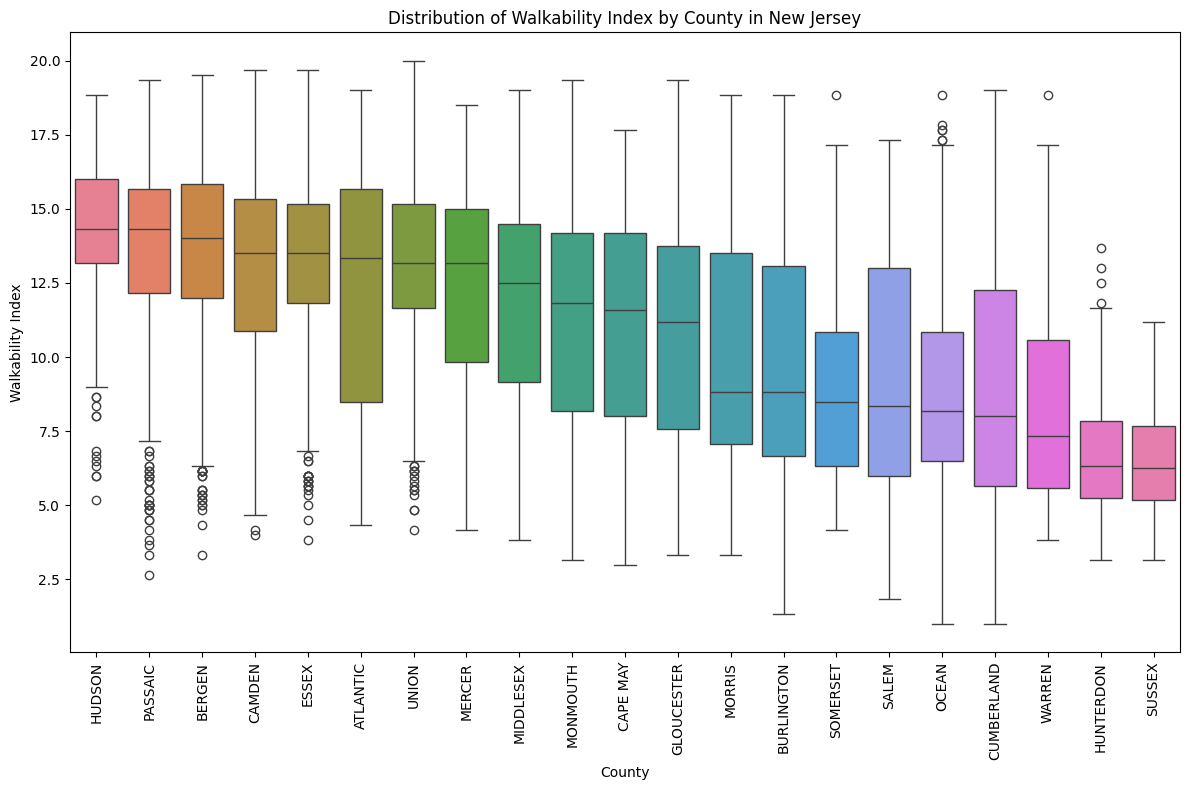

In [ ]:
# Sort counties by median Walkability Index
sorted_data = merged_data_counties.copy()
sorted_data['COUNTY'] = pd.Categorical(
    sorted_data['COUNTY'],
    categories=sorted_data.groupby('COUNTY')['NatWalkInd'].median().sort_values(ascending=False).index,
    ordered=True
)

# Set a color palette with unique colors for each box
palette = sns.color_palette("husl", n_colors=sorted_data['COUNTY'].nunique())

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(
    x="COUNTY",
    y="NatWalkInd",
    data=sorted_data,
    palette=palette
)
plt.xlabel("County")
plt.ylabel("Walkability Index")
plt.title("Distribution of Walkability Index by County in New Jersey")
plt.xticks(rotation=90)
plt.tight_layout()  # Adjust layout for better visibility
plt.show()

Feature Selection for Modeling

In [ ]:
#First do a correlation matrix on the walkability index column and
#the other columns to identify the strongest relationships.
correlation_matrix = smart_location_data.corr()
print(correlation_matrix["NatWalkInd"].sort_values(ascending=False))

NatWalkInd      1.000000
D4A_Ranked      0.868928
D5DEI           0.834310
D5DRI           0.834310
D5DR            0.834310
D5DE            0.834310
D4A             0.833099
D3B_Ranked      0.721743
D3A             0.662951
D4D             0.631357
D4C             0.630239
D4E             0.630172
D3B             0.606083
D5BE            0.564181
D3APO           0.556642
D5AR            0.496230
D5AE            0.496125
D5CRI           0.495395
D5CEI           0.484887
D5BR            0.412121
D3BPO4          0.384718
D3BMM3          0.383981
D3BPO3          0.367072
D3BMM4          0.362544
D1D             0.356212
Pct_AO0         0.353914
D1B             0.345073
Pct_AO1         0.322716
D1A             0.321318
D3AMM           0.315735
D2C_TRPMX2      0.311760
D4B050          0.302194
D2A_EPHHM       0.294304
D2C_TRPMX1      0.293839
D2B_Ranked      0.292695
D1C8_RET        0.292036
D1C5_RET        0.292036
D2A_Ranked      0.287426
D2B_E8MIXA      0.285134
AutoOwn0        0.266283


## Feature Selection

In [ ]:
#Select features relevant to your target variable and include the suggestions from ChatGPT
#X = smart_location_data[["D5DRI", "D5DEI", "D5DR", "D5DE", "D4A", "D3A", "D4D", "D4C", "D4E", "D3APO", "D3B", "D5BE", "D3BPO3", "D5CEI", "D5AR", "D5CRI", "D5AE", "D3BPO4", "D3BMM4", "D1A", "D1B", "D1C", "AutoOwn0", "D1D"]]
#X = smart_location_data[["CBSA_POP", "CBSA_EMP", "CBSA_WRK", "D4A", "D5DRI", "D5DEI", "D5DE", "D3BPO4", "D3A", "D3BPO3", "D3APO", "D3BMM4", "AutoOwn0"]]
#X = smart_location_data[["D4A_Ranked", "D5DRI", "D5DEI", "D5DR","D5DE", "D3B_Ranked", "D3A", "D4D", "D4C", "D3APO", "D5BE", "D5AE", "Pct_AO0", "D1A"]]
#X = smart_location_data[["D4A_Ranked", "D5DE", "D3B_Ranked", "D3A", "D4D", "D4C", "D3APO", "D5BE", "D5AE", "Pct_AO0", "D1A"]]
X = smart_location_data[["D4A_Ranked", "D3B_Ranked", "D4D", "D5BE", "Pct_AO0", "D1A"]]
y = smart_location_data["NatWalkInd"]
X.shape

(6320, 6)

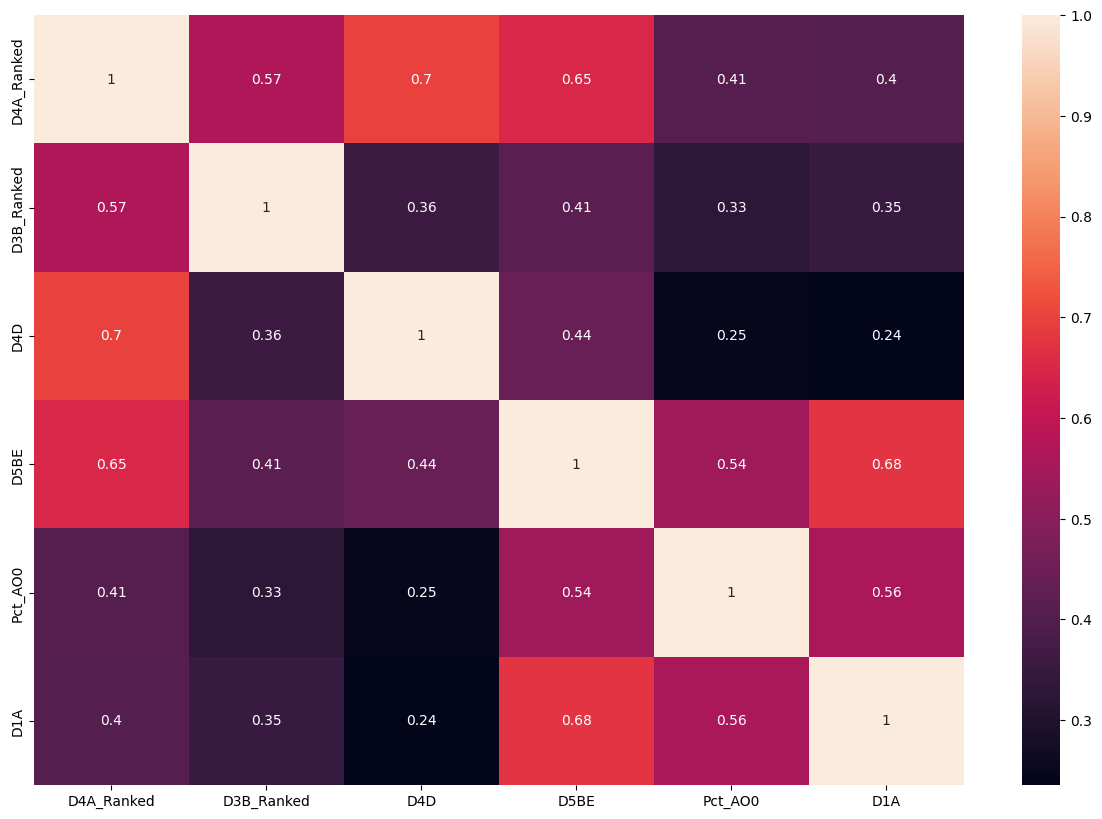

In [ ]:
#Next create a correlation matrix
numeric_features = X.select_dtypes(include=np.number)
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(15,10))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [ ]:
#Check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

      feature       VIF
0  D4A_Ranked  8.700816
1  D3B_Ranked  8.939197
2         D4D  1.719545
3        D5BE  2.646979
4     Pct_AO0  2.533798
5         D1A  3.044310


Split the data

In [ ]:
#Split the data into training and testing subsets for evaluation.
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2,random_state=0)

## Regression
## 1. Decision Trees

In [ ]:
#Decision Tree - Create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.
dt = DecisionTreeRegressor(random_state=0)
dt_scores = cross_val_score(dt, X_train, y_train, scoring="r2", cv=10)
print("Decision Tree Scores: %.2f +/- %.2f" % (dt_scores.mean(), dt_scores.std()))

Decision Tree Scores: 0.71 +/- 0.02


In [ ]:
#Decision Tree Tuning
parameter = {"max_features": ["auto", "sqrt", "log2"]}
dt_grid = GridSearchCV(dt, parameter, scoring = "r2", cv = 10)
dt_grid.fit(X_train, y_train)
print("best parameter of ridge is: %s"%dt_grid.best_params_)

best parameter of ridge is: {'max_features': 'sqrt'}


In [ ]:
print("average of r2 across 10 folds for the best parameter: %.2f, std dev : %.2f"
      %(dt_grid.best_score_, dt_grid.cv_results_["std_test_score"][dt_grid.best_index_]))

average of r2 across 10 folds for the best parameter: 0.70, std dev : 0.03


In [ ]:
dt = DecisionTreeRegressor(random_state=0, max_features="sqrt")  # or max_features="sqrt"
parameter = {"min_samples_leaf": [2, 4, 6, 8, 10, 12, 14]}
dt_grid = GridSearchCV(dt, parameter, scoring="r2", cv=10)
dt_grid.fit(X_train, y_train)
print("best parameter of ridge is: %s" % dt_grid.best_params_)

best parameter of ridge is: {'min_samples_leaf': 14}


In [ ]:
print("average of r2 across 10 folds for the best parameter: %.2f, std dev : %.2f"
      %(dt_grid.best_score_, dt_grid.cv_results_["std_test_score"][dt_grid.best_index_]))

average of r2 across 10 folds for the best parameter: 0.82, std dev : 0.01


Check to see how the model performance differ by min_sample size

In [ ]:
dt_grid.cv_results_["mean_test_score"]

array([0.74067716, 0.78568957, 0.79919596, 0.80576902, 0.81364813,
       0.81345438, 0.81663124])

In [ ]:
dt = DecisionTreeRegressor(random_state=0, max_features="sqrt")  # or max_features="sqrt"
parameter = {"min_samples_leaf": list(range(10, 20, 2))}
dt_grid = GridSearchCV(dt, parameter, scoring="r2", cv=10)
dt_grid.fit(X_train, y_train)

print("best parameter of ridge is: %s" % dt_grid.best_params_)
print("average of r2 across 10 folds for the best parameter: %.2f, std dev : %.2f"
      % (dt_grid.best_score_, dt_grid.cv_results_["std_test_score"][dt_grid.best_index_]))

best parameter of ridge is: {'min_samples_leaf': 16}
average of r2 across 10 folds for the best parameter: 0.82, std dev : 0.01


In [ ]:
dt = DecisionTreeRegressor(random_state=0, max_features="sqrt", min_samples_leaf=16)
dt_scores = cross_val_score(dt, X_train, y_train, scoring="r2", cv=10)
print("DT Model with Data Scores: %.2f +/- %.2f" % (dt_scores.mean(), dt_scores.std()))

DT Model with Data Scores: 0.82 +/- 0.01


Decision Tree Model Visualization

In [ ]:
#Perform a Decision Tree Model Visualization
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_features='sqrt', min_samples_leaf=16, random_state=0)

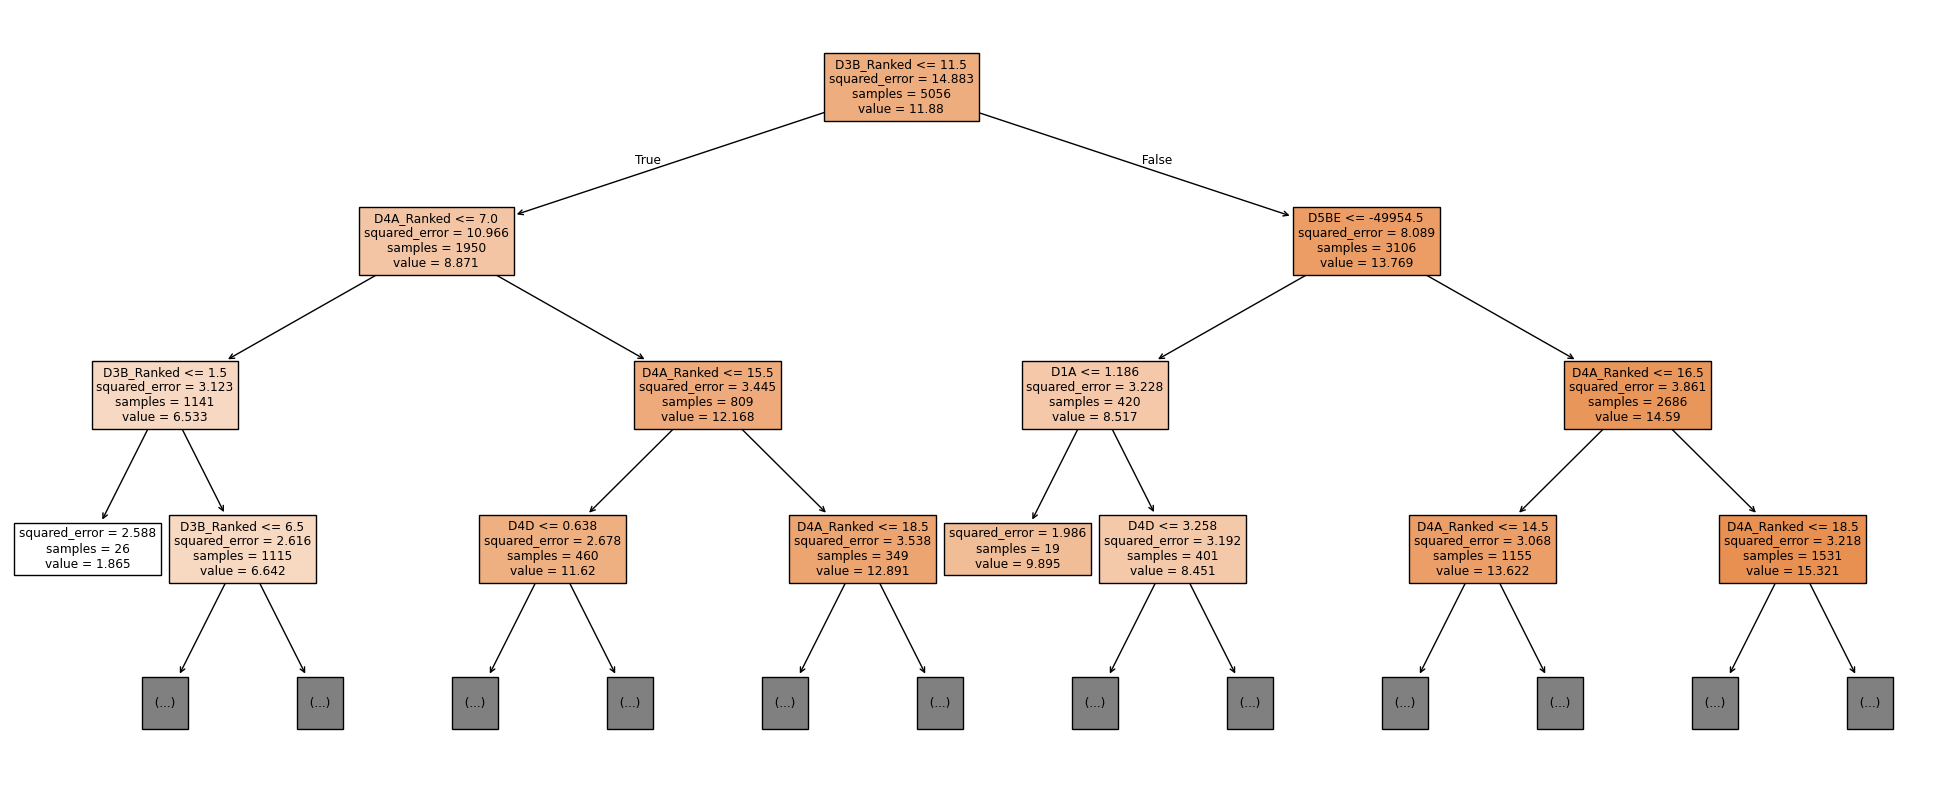

In [ ]:
fig = plt.figure(figsize=(25,10))
_ = tree.plot_tree(dt,
                   max_depth = 3, # only plot out the first 2 level of trees
                   feature_names=X.columns,
                   filled=True)

Use TRACTCE and use labelencoder for the TRACTCE column

# 2. Linear Regression Model

In [ ]:
#Linear Regression Model
lin = LinearRegression()
lin_scores = cross_val_score(lin, X_train, y_train, scoring="r2", cv=10)
print("Linear Regression Scores: %.2f +/- %.2f" % (lin_scores.mean(), lin_scores.std()))

Linear Regression Scores: 0.84 +/- 0.01


# 3. Random Forest

Train a default random forest regresor

In [ ]:
#Default Random Forest
start = time.time()
rf = RandomForestRegressor(random_state=0)
rf_scores = cross_val_score(rf, X_train, y_train, scoring="r2", cv=10)
print("Random Forest Scores: %.2f +/- %.2f" % (rf_scores.mean(), rf_scores.std()))
print("time to run this experiment: %.2f"%(time.time()-start))


Random Forest Scores: 0.84 +/- 0.01
time to run this experiment: 27.44


In [ ]:
rf.fit(X_train, y_train)
rf_imp_score = pd.DataFrame({
    "features" : X.columns,
    "score" : rf.feature_importances_})
rf_imp_score.sort_values("score", ascending = False).head(20)

,features,score
3,D5BE,0.576094
0,D4A_Ranked,0.183740
1,D3B_Ranked,0.116500
5,D1A,0.061853
4,Pct_AO0,0.033187
2,D4D,0.028626


Tuning Random Forest Model

In [ ]:
#Fine Tune the Random Forest Model
rf = RandomForestRegressor(random_state=0)
parameter = {"min_samples_leaf":[6,10,12]}
rf_grid1 = GridSearchCV(rf, parameter, scoring = "r2", cv = 10)
rf_grid1.fit(X_train, y_train)
print("best parameter of rf's min_sample_leaf parameter is: %s"%rf_grid1.best_params_)

best parameter of rf's min_sample_leaf parameter is: {'min_samples_leaf': 12}


In [ ]:
print("average of r2 across 10 folds for the best parameter: %.2f, std dev : %.2f"
      %(rf_grid1.best_score_, rf_grid1.cv_results_["std_test_score"][rf_grid1.best_index_]))

average of r2 across 10 folds for the best parameter: 0.85, std dev : 0.01


In [ ]:
rf_grid1.cv_results_["mean_test_score"]

array([0.8479069 , 0.84882843, 0.849072  ])

Fine tune the number of tree (from 80 to 160, with an increasing step of 20), while control the min_sample_leaf to 12

In [ ]:
rf = RandomForestRegressor(random_state=0, min_samples_leaf=12)
parameter = {"n_estimators": list(range(80, 160, 20))}
rf_grid2 = GridSearchCV(rf, parameter, scoring="r2", cv=10)
rf_grid2.fit(X_train, y_train)
print("best parameter of rf's n_estimators parameter is: %s" % rf_grid2.best_params_)
print("average of r2 across 10 folds for the best parameter: %.2f, std dev : %.2f"
      %(rf_grid2.best_score_, rf_grid2.cv_results_["std_test_score"][rf_grid2.best_index_]))

best parameter of rf's n_estimators parameter is: {'n_estimators': 140}
average of r2 across 10 folds for the best parameter: 0.85, std dev : 0.01


Fine tune RF model for max_features parameter ranging from 6 to 9.

In [ ]:
rf = RandomForestRegressor(random_state= 0, min_samples_leaf = 12, n_estimators = 140)
parameter = {"max_features": [6,7,8,9]}
rf_grid2 = GridSearchCV(rf, parameter, scoring = "r2", cv = 10)
rf_grid2.fit(X_train, y_train)
print("best parameter of rf's max_features parameter is: %s"%rf_grid2.best_params_)
print("average of r2 across 10 folds for the best parameter: %.2f, std dev : %.2f"
      %(rf_grid2.best_score_, rf_grid2.cv_results_["std_test_score"][rf_grid2.best_index_]))

best parameter of rf's max_features parameter is: {'max_features': 6}
average of r2 across 10 folds for the best parameter: 0.85, std dev : 0.01


# 4. Gradient Boosting Model

In [ ]:
#Default Gradient Boosting Model
start= time.time()
#initialize the gb model
gb = GradientBoostingRegressor(random_state=0)
gb_scores = cross_val_score(gb,
                            X_train, y_train,
                            scoring = "r2", cv = 10)
print("Default Gradient Boosting Model Scores: %.2f +/- %.2f"%(gb_scores.mean(), gb_scores.std()))
print("time to run this experiment: %.2f"%(time.time()-start))

Default Gradient Boosting Model Scores: 0.85 +/- 0.01
time to run this experiment: 10.10


In [ ]:
# Fine tune a GBM

# Define the model
# The list of hyper-parameters we want to optimize. For each one we define the
# bounds, the corresponding scikit-learn parameter name, as well as how to
# sample values from that dimension (`'log-uniform'` for the learning rate)
space = [Integer(60,100, name="n_estimators"),
            Integer(5, 12, name='max_depth'),
          Real(0.01, 1, "log-uniform", name='learning_rate'),
          Integer(2, 13, name='max_features'),
          Integer(100, 150, name='min_samples_split')]

gb = GradientBoostingRegressor(random_state=0)

# this decorator allows your objective function to receive a the parameters as
# keyword arguments.
@use_named_args(space)
def objective(**params):
    gb.set_params(**params)

    return -np.mean(cross_val_score(gb, X_train, y_train, cv=10, n_jobs=-1,
                                    scoring="r2"))

gb_gp_mae = gp_minimize(objective, space, n_calls=50, random_state=0)

In [ ]:
gb_gp = gp_minimize(objective, space, n_calls=50, random_state=0)

"Best score=%.4f" % gb_gp.fun

'Best score=-0.8541'

In [ ]:
#Print the best parameters
print("""Best parameters:
- n_estimators = %d
- max_depth=%d
- learning_rate=%.6f
- max_features=%d
- min_samples_split=%d""" %(gb_gp.x[0], gb_gp.x[1],
                            gb_gp.x[2], gb_gp.x[3],
                            gb_gp.x[4]))

Best parameters:
- n_estimators = 80
- max_depth=5
- learning_rate=0.088591
- max_features=2
- min_samples_split=150


# Model test on the test set

How does the linear regression model perform on the test dataset?

In [ ]:
#Model performance on testing set with linear regression model
lin.fit(X_train, y_train)
y_pred = lin.predict(X_valid)
r2_score(y_pred, y_valid)

0.818953422204216

How does the random forest model perform on the test dataset?

In [ ]:
rf = RandomForestRegressor(random_state= 0, min_samples_leaf = 12, max_features= 6, n_estimators = 140)
rf.fit(X_train, y_train)

#Model performance on testing set with random forest
rf.fit(X_train, y_train)
y_pred = rf.predict(X_valid)
r2_score(y_pred, y_valid)

0.825450486280991

How does the gradient boosting model perform on the test dataset?

In [ ]:
start = time.time()
gb = GradientBoostingRegressor(random_state=0, max_depth=5, learning_rate = 0.088591, n_estimators = 80, max_features = 2, min_samples_split = 150)
gb_scores = cross_val_score(gb, X_train, y_train, scoring = "r2", cv = 10)
print("Gradient Boosting Model Scores on the dataset: %.2f +/- %.2f"%(gb_scores.mean(), gb_scores.std()))
print("time to run this experiment: %.2f"%(time.time()-start))

Gradient Boosting Model Scores on the dataset: 0.85 +/- 0.01
time to run this experiment: 5.89


In [ ]:
#Model performance on testing set with gradient boosting model
gb.fit(X_train, y_train)

y_pred = gb.predict(X_valid)
r2_score(y_pred, y_valid)

0.8320460962143674

# Classification

Create bins for classification, split data into training and testing subsets for evaluation, and check to see if the data is balanced

In [ ]:
bins = [0, 5, 10, 15, 20]  # 4 bin edges create 3 intervals
labels = ["Very Low", "Low", "Medium", "High"]  # 4 labels for the 3 intervals
smart_location_data["WalkabilityCategory"] = pd.cut(smart_location_data["NatWalkInd"], bins=bins, labels=labels)

In [ ]:
#Split the data into training and testing subsets for evaluation.
X = smart_location_data[["D4A_Ranked", "D3B_Ranked", "D4D", "D5BE", "Pct_AO0", "D1A"]]
y = smart_location_data["WalkabilityCategory"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2,random_state=0)

In [ ]:
#Check to see if the data is balanced
y_train.head()
y_train.value_counts()


,count
WalkabilityCategory,
Medium,2326
Low,1354
High,1146
Very Low,230


Balance the data

In [ ]:
smart_location_data_combined = X_train.copy()
smart_location_data_combined = smart_location_data_combined.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
smart_location_data_combined["WalkabilityCategory"] = y_train

# Separate the data by WalkabilityCategory column
very_low = smart_location_data_combined[smart_location_data_combined["WalkabilityCategory"] == "Very Low"]
low = smart_location_data_combined[smart_location_data_combined["WalkabilityCategory"] == "Low"]
medium = smart_location_data_combined[smart_location_data_combined["WalkabilityCategory"] == "Medium"]
high = smart_location_data_combined[smart_location_data_combined["WalkabilityCategory"] == "High"]

# Determine the target count (maximum class count for upsampling)
target_count = max(len(low), len(medium), len(high))

# Upsample minority classes to match the target count
very_low_upsampled = resample(
    very_low,
    replace=True,  # Sample with replacement
    n_samples=target_count,  # Match the target count
    random_state=0  # Ensure reproducibility
)

low_upsampled = resample(
    low,
    replace=True,  # Sample with replacement
    n_samples=target_count,
    random_state=0
)

high_upsampled = resample(
    high,
    replace=True,  # Sample with replacement
    n_samples=target_count,
    random_state=0
)

# Combine all data back together
upsampled_data = pd.concat([very_low_upsampled, low_upsampled, medium, high_upsampled])

# Shuffle the dataset to mix the samples
upsampled_data = upsampled_data.sample(frac=1, random_state=0).reset_index(drop=True)

# Check the new distribution
print(upsampled_data["WalkabilityCategory"].value_counts())

WalkabilityCategory
Very Low    2326
Low         2326
Medium      2326
High        2326
Name: count, dtype: int64


In [ ]:
#Split the upsampled data into X_upsampled and y_upsampled
X_upsampled = upsampled_data.drop("WalkabilityCategory", axis=1)
y_upsampled = upsampled_data["WalkabilityCategory"]

In [ ]:
#View the X_upsampled data
print(X_upsampled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9304 entries, 0 to 9303
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   D4A_Ranked  9304 non-null   int64  
 1   D3B_Ranked  9304 non-null   int64  
 2   D4D         9304 non-null   float64
 3   D5BE        9304 non-null   int64  
 4   Pct_AO0     9304 non-null   float64
 5   D1A         9304 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 436.3 KB
None


## 1. Random Forest Classifier

In [ ]:
#Default Random Forest Classifier
rfc = RandomForestClassifier()
rfc.fit(X_upsampled, y_upsampled)
y_predict_rf = rfc.predict(X_valid)

precision, recall, fscore, support = score(y_valid, y_predict_rf)
print(len(precision), len(recall), len(fscore), len(support))

df_rf = pd.DataFrame({
    "labels": ["Very Low", "Low", "Medium", "High"],  # Adjusted labels for binary classification
    'precision': precision,
    "recall": recall,
    "fscore": fscore,
    "support": support
})

print(df_rf)

print("accuracy score of random forest: ", accuracy_score(y_predict_rf, y_valid))
print("precision score of random forest: ", precision_score(y_predict_rf, y_valid, average = "weighted"))
print("Recall score of random forest: ", recall_score(y_predict_rf, y_valid, average = "weighted"))

4 4 4 4
     labels  precision    recall    fscore  support
0  Very Low   0.606618  0.600000  0.603291      275
1       Low   0.820359  0.767507  0.793054      357
2    Medium   0.749585  0.772650  0.760943      585
3      High   0.236364  0.276596  0.254902       47
accuracy score of random forest:  0.7151898734177216
precision score of random forest:  0.7125536370258808
Recall score of random forest:  0.7151898734177216


In [ ]:
#Fine Tuned Random Forest Classifier
rfc = RandomForestClassifier(random_state= 0)
param_grid = {
    "n_estimators":[80, 160, 20],
    'max_depth': [3, 5, 10],          # Depth of each tree
    'min_samples_split': [2, 5, 10],   # Minimum samples required to split a node
    #"max_features": [6,7,8,9,10,11,12],
    "min_samples_leaf": [1,2,3]
}

rfc_grid1 = GridSearchCV(rfc, param_grid, scoring = "f1_macro", cv = 10)
rfc_grid1.fit(X_upsampled, y_upsampled)
print("Best parameter are: %s"%rfc_grid1.best_params_)
print("Best F1-score:", rfc_grid1.best_score_)

Best parameter are: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 80}
Best F1-score: 0.8461879732028089


Prediction using Random Forest Classifier

In [ ]:
rfc = RandomForestClassifier(random_state=0, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=80)
rfc.fit(X_upsampled, y_upsampled)
y_predict_rf = rfc.predict(X_valid)

precision, recall, fscore, support = score(y_valid, y_predict_rf)

df_rf = pd.DataFrame({
    "labels": ["Very Low", "Low", "Medium", "High"],  # Adjusted labels for binary classification
    'precision': precision,
    "recall": recall,
    "fscore": fscore,
    "support": support
})

print(df_rf)

print("accuracy score of random forest: ", accuracy_score(y_predict_rf, y_valid))
print("precision score of random forest: ", precision_score(y_predict_rf, y_valid, average = "weighted"))
print("Recall score of random forest: ", recall_score(y_predict_rf, y_valid, average = "weighted"))

     labels  precision    recall    fscore  support
0  Very Low   0.596386  0.720000  0.652389      275
1       Low   0.837545  0.649860  0.731861      357
2    Medium   0.799250  0.728205  0.762075      585
3      High   0.221311  0.574468  0.319527       47
accuracy score of random forest:  0.6985759493670886
precision score of random forest:  0.6940424400301463
Recall score of random forest:  0.6985759493670886


## 2. Gradient Boosting Classifier

In [ ]:
#Default Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=0)
gbc.fit(X_upsampled, y_upsampled)
y_predict_gbc = gbc.predict(X_valid)

precision, recall, fscore, support = score(y_valid, y_predict_gbc)

df_gb = pd.DataFrame({
    "labels": ["Very Low", "Low", "Medium", "High"],  # Adjusted labels for binary classification
    'precision': precision,
    "recall": recall,
    "fscore": fscore,
    "support": support
})

print(df_gb)

print("accuracy score of gradient boosting: ", accuracy_score(y_predict_gbc, y_valid))
print("precision score of gradient boosting: ", precision_score(y_predict_gbc, y_valid, average = "weighted"))
print("Recall score of gradient boosting: ", recall_score(y_predict_gbc, y_valid, average = "weighted"))

     labels  precision    recall    fscore  support
0  Very Low   0.594752  0.741818  0.660194      275
1       Low   0.839161  0.672269  0.746501      357
2    Medium   0.806576  0.712821  0.756806      585
3      High   0.245763  0.617021  0.351515       47
accuracy score of gradient boosting:  0.7041139240506329
precision score of gradient boosting:  0.7025706168458581
Recall score of gradient boosting:  0.7041139240506329


In [ ]:
# Fine Tuned Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state= 0)
param_grid = {
    "n_estimators":[80,100,120],
    'max_depth': [3, 5, 10],          # Depth of each tree
    'min_samples_split': [2, 5, 10],   # Minimum samples required to split a node
    #"max_features": [6,7,8,9,10,11,12],
    "min_samples_leaf": [1,2,3]
}

gbc_grid1 = GridSearchCV(gbc, param_grid, scoring = "f1_macro", cv = 10)
gbc_grid1.fit(X_upsampled, y_upsampled)
print("Best parameter are: %s"%gbc_grid1.best_params_)
print("Best F1-score:", gbc_grid1.best_score_)

Best parameter are: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 120}
Best F1-score: 0.9197973250943001


Prediction using Gradient Boosting Classifier

In [ ]:
gbc = GradientBoostingClassifier(random_state=0, max_depth=10, min_samples_leaf=1, min_samples_split=10, n_estimators=120)
gbc.fit(X_upsampled, y_upsampled)
y_predict_gbc = gbc.predict(X_valid)

precision, recall, fscore, support = score(y_valid, y_predict_gbc)

df_gb = pd.DataFrame({
    "labels": ["Very Low", "Low", "Medium", "High"],  # Adjusted labels for binary classification
    'precision': precision,
    "recall": recall,
    "fscore": fscore,
    "support": support
})

print(df_gb)

print("accuracy score of gradient boosting: ", accuracy_score(y_predict_gbc, y_valid))
print("precision score of gradient boosting: ", precision_score(y_predict_gbc, y_valid, average = "weighted"))
print("Recall score of gradient boosting: ", recall_score(y_predict_gbc, y_valid, average = "weighted"))

NameError: name 'GradientBoostingClassifier' is not defined

## Confusion Matrix for Random Forest Classifier

In [ ]:
#Confusion matrix Random Forest Classifier
cm = confusion_matrix(y_valid, y_predict_rf)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Very Low", "Low", "Medium", "High"]) # Adjust display_labels as needed
disp.plot()
plt.show()

## Confusion Matrix for Gradient Boosting Classifier

In [ ]:
#Confusion matrix Gradient Boosting Classifier
cm = confusion_matrix(y_valid, y_predict_gbc)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Very Low", "Low", "Medium", "High"]) # Adjust display_labels as needed
disp.plot()
plt.show()